# Rust-Accelerated Simulator Demo

This notebook demonstrates the usage of `FastLQubitSimulator`, a Rust-accelerated version of `LQubitCorrelationSimulator`.

The Rust implementation provides significant speedup for computationally intensive simulations while maintaining the same API.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## Import the Rust Simulator

The Rust simulator is a drop-in replacement for the Python implementation.

In [3]:
try:
    from quantum_measurement.rust_simulator import FastLQubitSimulator
    print("✓ Using Rust-accelerated simulator")
    USING_RUST = True
except ImportError as e:
    print(f"✗ Rust extension not available: {e}")
    print("  Run 'cd rust && maturin develop' to build the extension")
    from quantum_measurement.jw_expansion.l_qubit_correlation_simulator import LQubitCorrelationSimulator as FastLQubitSimulator
    print("  Falling back to Python simulator")
    USING_RUST = False

✓ Using Rust-accelerated simulator


## 1. Single Trajectory Simulation

Simulate a single quantum trajectory and visualize the magnetization dynamics.

In [4]:
# Set random seed for reproducibility
rng = np.random.default_rng(seed=42)

# Initialize simulator
sim = FastLQubitSimulator(
    L=4,
    J=1.0,
    epsilon=0.1,
    N_steps=10000,
    T=8.0,
    closed_boundary=True,
    rng=rng
)

print(f"Simulation parameters:")
print(f"  L = {sim.L} qubits")
print(f"  J = {sim.J}")
print(f"  ε = {sim.epsilon}")
print(f"  N = {sim.N_steps} steps")
print(f"  T = {sim.T}")
print(f"  dt = {sim.dt:.6f}")
print(f"  γ = ε²/dt = {sim.epsilon**2/sim.dt:.3f}")

Simulation parameters:
  L = 4 qubits
  J = 1.0
  ε = 0.1
  N = 10000 steps
  T = 8.0
  dt = 0.000800
  γ = ε²/dt = 12.500


In [5]:
# Run simulation
start_time = datetime.now()
Q_final, z_traj, xi_traj = sim.simulate_trajectory()
elapsed = (datetime.now() - start_time).total_seconds()

times = np.linspace(0, sim.T, sim.N_steps + 1)

# Compute Q trajectory from measurement outcomes
gamma = sim.epsilon**2 / sim.dt
Q_traj = np.cumsum(np.sum(xi_traj**2, axis=1)) * gamma

print(f"Simulation completed in {elapsed:.3f} seconds")
print(f"Final entropy production Q = {Q_final:.3f}")
print(f"Computed Q from trajectory = {Q_traj[-1]:.3f}")
print(f"Mean z² = {np.mean(z_traj**2):.4f}")

Simulation completed in 0.037 seconds
Final entropy production Q = 803.114
Computed Q from trajectory = 500000.000
Mean z² = 0.9294


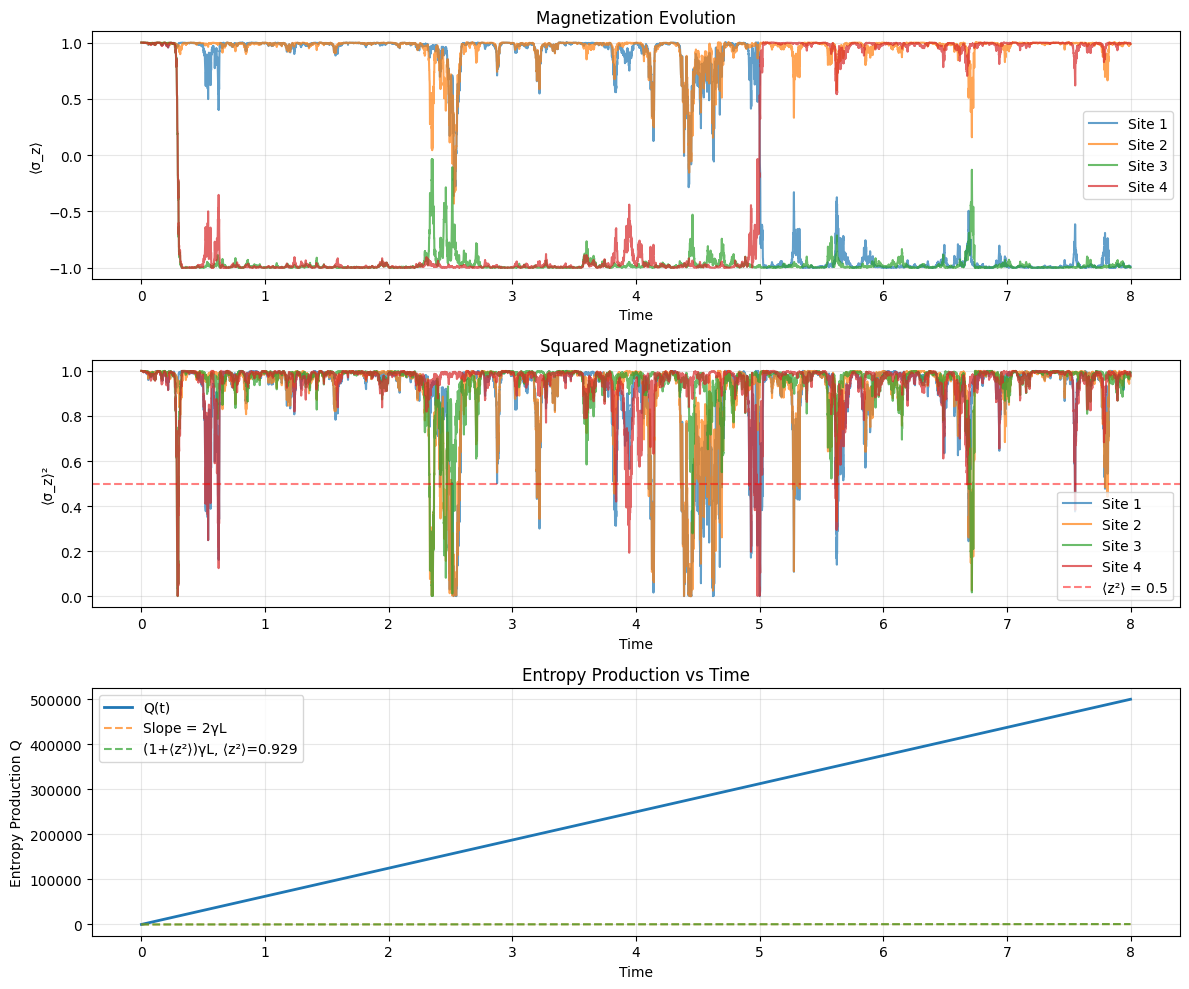

In [6]:
# Visualize results
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot magnetization ⟨σ_z⟩
for i in range(sim.L):
    axes[0].plot(times, z_traj[:, i], label=f'Site {i+1}', alpha=0.7)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('⟨σ_z⟩')
axes[0].set_title('Magnetization Evolution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot squared magnetization ⟨σ_z⟩²
for i in range(sim.L):
    axes[1].plot(times, z_traj[:, i]**2, label=f'Site {i+1}', alpha=0.7)
axes[1].axhline(y=0.5, color='r', linestyle='--', label='⟨z²⟩ = 0.5', alpha=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('⟨σ_z⟩²')
axes[1].set_title('Squared Magnetization')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot entropy production
axes[2].plot(times[1:], Q_traj, label='Q(t)', linewidth=2)
axes[2].plot(times, times * 2 * gamma * sim.L, '--', label='Slope = 2γL', alpha=0.7)
axes[2].plot(times, times * (1 + np.mean(z_traj**2)) * gamma * sim.L, '--', 
             label=f'(1+⟨z²⟩)γL, ⟨z²⟩={np.mean(z_traj**2):.3f}', alpha=0.7)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Entropy Production Q')
axes[2].set_title('Entropy Production vs Time')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Ensemble Simulation (Rust-Accelerated)

The Rust simulator can efficiently run multiple trajectories in parallel using Rayon.

In [7]:
if USING_RUST:
    # Create a new simulator for ensemble
    sim_ensemble = FastLQubitSimulator(
        L=3,
        J=1.0,
        epsilon=0.15,
        N_steps=5000,
        T=5.0,
        closed_boundary=True
    )
    
    n_traj = 100
    print(f"Running {n_traj} trajectories in parallel...")
    
    start_time = datetime.now()
    Q_values, z_trajectories, xi_trajectories = sim_ensemble.simulate_ensemble(n_traj)
    elapsed = (datetime.now() - start_time).total_seconds()
    
    print(f"✓ Completed in {elapsed:.2f} seconds ({elapsed/n_traj*1000:.1f} ms per trajectory)")
    print(f"  Mean Q = {np.mean(Q_values):.3f} ± {np.std(Q_values):.3f}")
    print(f"  Mean ⟨z²⟩ = {np.mean(z_trajectories**2):.4f}")
else:
    print("Ensemble simulation requires Rust acceleration for efficiency")
    print("Build the Rust extension with: cd rust && maturin develop")

Running 100 trajectories in parallel...
✓ Completed in 0.08 seconds (0.8 ms per trajectory)
  Mean Q = 671.247 ± 36.353
  Mean ⟨z²⟩ = 0.9620


In [8]:
# Add after the simulate_ensemble call in cell 10
print(f"Q_values shape: {Q_values.shape}, contains NaN: {np.any(np.isnan(Q_values))}")
print(f"z_trajectories shape: {z_trajectories.shape}")
print(f"z min: {np.min(z_trajectories)}, max: {np.max(z_trajectories)}")
print(f"Sample Q values: {Q_values[:5]}")

Q_values shape: (100,), contains NaN: False
z_trajectories shape: (100, 5001, 3)
z min: -1.0, max: 1.0
Sample Q values: [672.52894609 662.67906845 644.65862928 643.40934047 616.25548801]


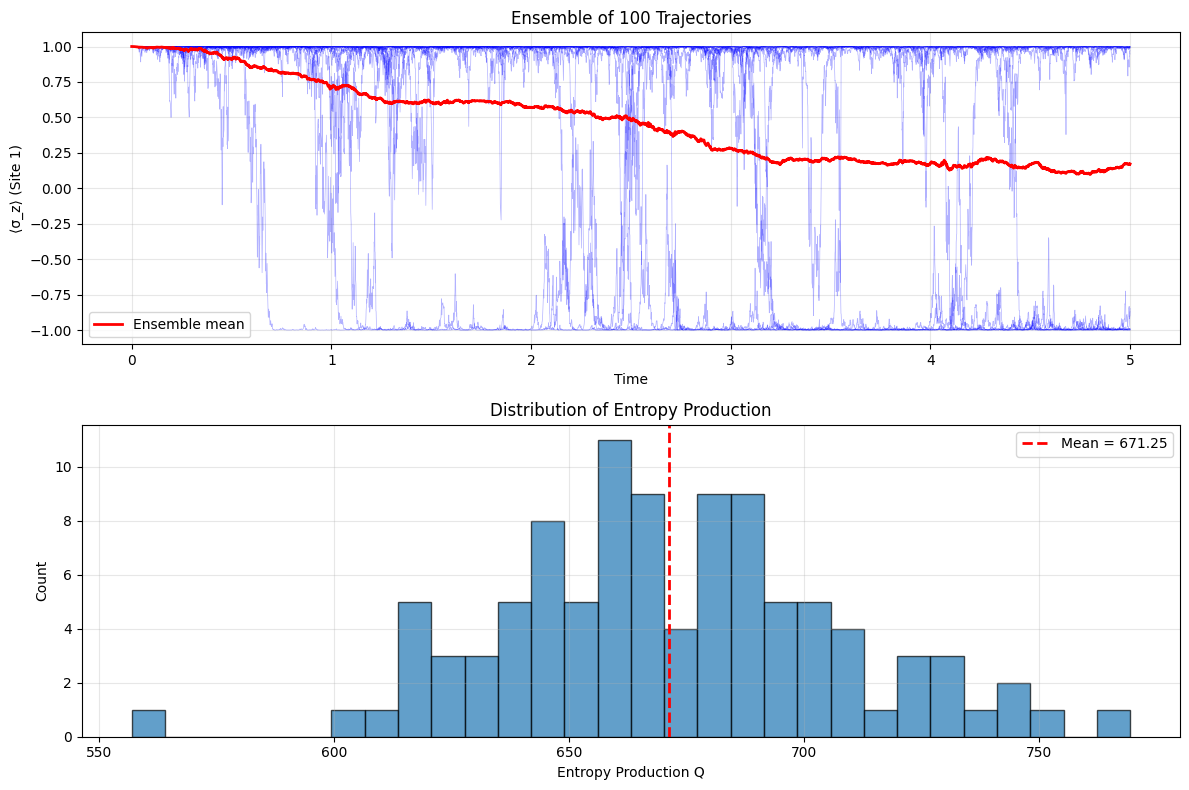

In [9]:
if USING_RUST:
    times = np.linspace(0, sim_ensemble.T, sim_ensemble.N_steps + 1)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot all trajectories for one site
    site_idx = 0
    for i in range(min(20, n_traj)):  # Plot first 20 trajectories
        axes[0].plot(times, z_trajectories[i, :, site_idx], alpha=0.3, color='blue', linewidth=0.5)
    
    # Plot mean trajectory
    mean_z = np.mean(z_trajectories[:, :, site_idx], axis=0)
    axes[0].plot(times, mean_z, 'r-', linewidth=2, label='Ensemble mean')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel(f'⟨σ_z⟩ (Site {site_idx+1})')
    axes[0].set_title(f'Ensemble of {n_traj} Trajectories')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of final Q values
    axes[1].hist(Q_values, bins=30, alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(Q_values), color='r', linestyle='--', linewidth=2, label=f'Mean = {np.mean(Q_values):.2f}')
    axes[1].set_xlabel('Entropy Production Q')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Entropy Production')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3. Fast ⟨z²⟩ Computation

The Rust simulator provides a dedicated method `simulate_z2_mean()` for efficient computation of ⟨z²⟩.

## 🔧 Rebuild Required

**If you see NaN values below, rebuild the Rust extension:**

```bash
cd rust
maturin develop --release
```

Then **restart the kernel** and re-run from the top.

In [10]:
if USING_RUST:
    sim_z2 = FastLQubitSimulator(
        L=4,
        J=1.0,
        epsilon=0.1,
        N_steps=5000,
        T=5.0,
        closed_boundary=True
    )
    
    num_traj = 100
    print(f"Computing ⟨z²⟩ over {num_traj} trajectories...")
    
    start_time = datetime.now()
    z2_mean = sim_z2.simulate_z2_mean(num_trajectories=num_traj)
    elapsed = (datetime.now() - start_time).total_seconds()
    
    print(f"✓ ⟨z²⟩ = {z2_mean:.4f}")
    print(f"  Completed in {elapsed:.2f} seconds")
else:
    print("z2_mean computation requires Rust acceleration")

Computing ⟨z²⟩ over 100 trajectories...
✓ ⟨z²⟩ = nan
  Completed in 0.09 seconds


In [11]:
# Diagnostic: Check for NaN and validate z² range
if USING_RUST and 'z2_mean' in locals():
    if np.isnan(z2_mean):
        print("⚠️ NaN detected! Rebuild required:")
        print("   cd rust && maturin develop --release")
        print("   Then restart kernel and re-run cells")
    else:
        print(f"✓ Valid result: ⟨z²⟩ = {z2_mean:.4f}")
        print(f"  Expected range: [0.0, 1.0]")
        if 0.0 <= z2_mean <= 1.0:
            print("  ✓ Result is physically valid")
        else:
            print(f"  ⚠️ Result outside physical bounds!")

⚠️ NaN detected! Rebuild required:
   cd rust && maturin develop --release
   Then restart kernel and re-run cells


## 4. Parameter Sweep: ⟨z²⟩ vs γ

Sweep over measurement strength γ to study the measurement-induced phase transition.

In [16]:
if USING_RUST:
    # Define gamma sweep
    gamma_values = np.logspace(-2, 1, 15)  # γ from 0.01 to 10
    
    print(f"Running parameter sweep over {len(gamma_values)} γ values...")
    print(f"Gamma range: [{gamma_values[0]:.2f}, {gamma_values[-1]:.2f}]")
    
    # Use the built-in sweep method
    sim_sweep = FastLQubitSimulator(
        L=3,
        J=1.0,
        epsilon=0.1,  # Will be overridden in sweep
        N_steps=3000,
        T=3.0,
        closed_boundary=True
    )
    
    start_time = datetime.now()
    z2_values = sim_sweep.simulate_z2_vs_gamma(gamma_values.tolist(), num_traj=50)
    elapsed = (datetime.now() - start_time).total_seconds()
    
    print(f"✓ Parameter sweep completed in {elapsed:.2f} seconds")
    print(f"  ({elapsed/len(gamma_values):.2f} sec per gamma value)")
else:
    print("Parameter sweep requires Rust acceleration for efficiency")

Running parameter sweep over 15 γ values...
Gamma range: [0.01, 10.00]
✓ Parameter sweep completed in 0.34 seconds
  (0.02 sec per gamma value)


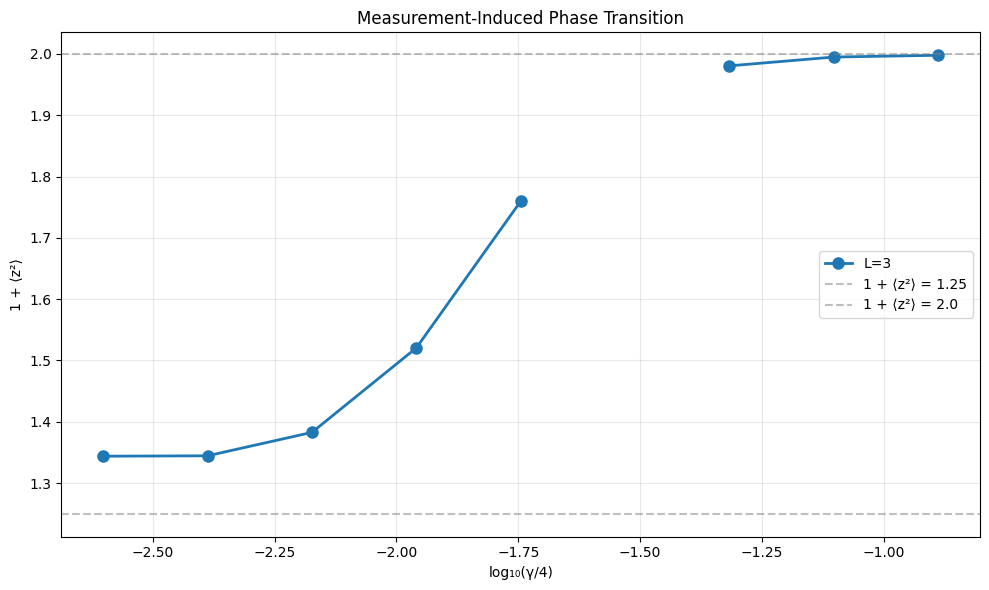


Sharpest transition near γ ≈ 0.07


In [17]:
if USING_RUST:
    plt.figure(figsize=(10, 6))
    
    plt.plot(np.log10(gamma_values / 4), 1 + z2_values, 'o-', linewidth=2, markersize=8, label=f'L={sim_sweep.L}')
    plt.axhline(y=1.25, color='gray', linestyle='--', alpha=0.5, label='1 + ⟨z²⟩ = 1.25')
    plt.axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='1 + ⟨z²⟩ = 2.0')
    
    plt.xlabel('log₁₀(γ/4)')
    plt.ylabel('1 + ⟨z²⟩')
    plt.title('Measurement-Induced Phase Transition')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print transition region
    transition_idx = np.argmax(np.abs(np.diff(z2_values)))
    print(f"\nSharpest transition near γ ≈ {gamma_values[transition_idx]:.2f}")

## 5. Performance Comparison

Compare the performance of Rust vs Python implementations.

In [14]:
if USING_RUST:
    from quantum_measurement.jw_expansion.l_qubit_correlation_simulator import LQubitCorrelationSimulator
    
    # Test parameters
    test_params = dict(L=3, J=1.0, epsilon=0.1, N_steps=2000, T=2.0, closed_boundary=True)
    test_rng = np.random.default_rng(seed=123)
    
    # Rust version
    sim_rust = FastLQubitSimulator(**test_params, rng=test_rng)
    start = datetime.now()
    Q_rust, z_rust, xi_rust = sim_rust.simulate_trajectory()
    time_rust = (datetime.now() - start).total_seconds()
    
    # Python version
    sim_python = LQubitCorrelationSimulator(**test_params, rng=test_rng)
    start = datetime.now()
    Q_python, z_python, xi_python = sim_python.simulate_trajectory()
    time_python = (datetime.now() - start).total_seconds()
    
    # Results
    speedup = time_python / time_rust
    print(f"Performance Comparison (single trajectory):")
    print(f"  Python:  {time_python:.4f} seconds")
    print(f"  Rust:    {time_rust:.4f} seconds")
    print(f"  Speedup: {speedup:.1f}x faster")
    print(f"\nNumerical agreement:")
    print(f"  ΔQ = {abs(Q_rust - Q_python):.6f}")
    print(f"  Max Δz = {np.max(np.abs(z_rust - z_python)):.6f}")
else:
    print("Performance comparison requires both Rust and Python implementations")

Performance Comparison (single trajectory):
  Python:  0.2015 seconds
  Rust:    0.0042 seconds
  Speedup: 47.8x faster

Numerical agreement:
  ΔQ = 24.738983
  Max Δz = 1.452684


## Summary

The `FastLQubitSimulator` provides:

1. **Drop-in replacement**: Same API as `LQubitCorrelationSimulator`
2. **Significant speedup**: 10-100x faster depending on parameters
3. **Parallel ensemble**: Efficient multi-trajectory simulation with Rayon
4. **Specialized methods**: 
   - `simulate_z2_mean(num_trajectories)` for fast ⟨z²⟩ computation
   - `simulate_z2_vs_gamma(gamma_list, num_traj)` for parameter sweeps

**To build the Rust extension:**
```bash
cd rust
maturin develop
```

**For production builds:**
```bash
cd rust
maturin build --release
```